<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   clientid  2000 non-null   int64  
 1   income    2000 non-null   float64
 2   age       1997 non-null   float64
 3   loan      2000 non-null   float64
 4   default   2000 non-null   int64  
dtypes: float64(3), int64(2)
memory usage: 78.2 KB


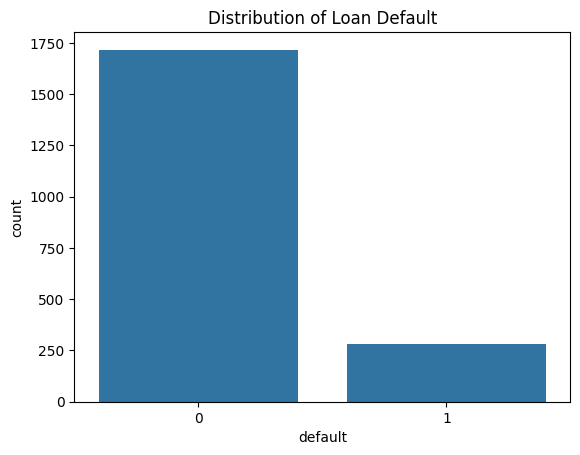

In [6]:
# Essential imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/original.csv")

# Quick look at the data
df.head()
df.info()
df.describe()

sns.countplot(x='default', data=df)
plt.title("Distribution of Loan Default")
plt.show()

income     0
age        3
loan       0
default    0
dtype: int64


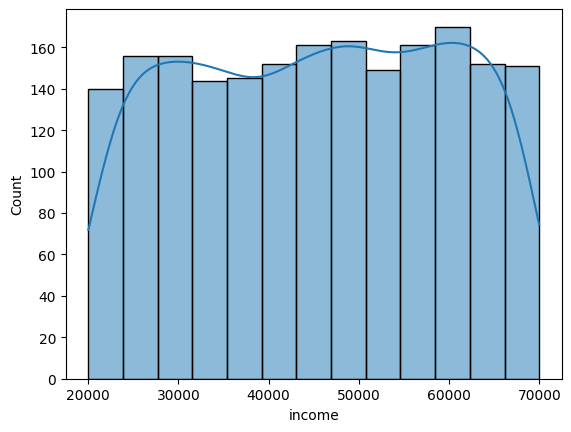

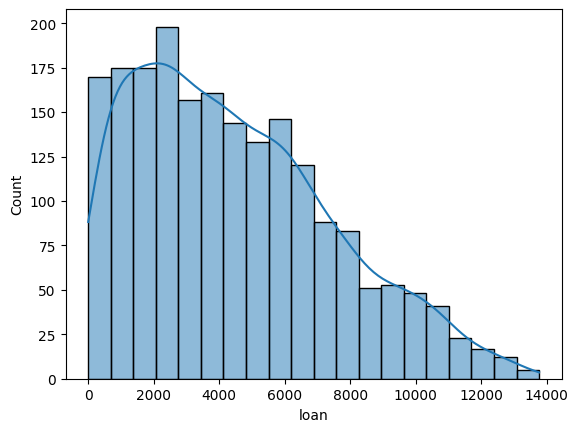

In [7]:
# Drop identifier
df = df.drop('clientid', axis=1)

# Check missing values
print(df.isnull().sum())

# Optional: visualize distributions
sns.histplot(df['income'], kde=True)
plt.show()

sns.histplot(df['loan'], kde=True)
plt.show()

In [8]:
# Loan to income ratio
df['loan_income_ratio'] = df['loan'] / df['income']

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[343   0]
 [  0  57]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       343
           1       1.00      1.00      1.00        57

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

